# Hyperparameter Tuning

This notebook uses Keras Tuner to optimize the neural network architecture and training hyperparameters based on validation performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import keras_tuner as kt

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
data_path = Path("../data/Datasets.xlsx")

df = pd.read_excel(
    data_path,
    sheet_name="Recruitment"
)

X = df.drop(columns=["Candidate_ID", "Status"])
y = df["Status"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [5]:
numerical_features = [
    "Experience",
    "Tech_Score",
    "Interview"
]

categorical_features = [
    "Position"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [6]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

input_size = X_train_processed.shape[1]

print("Input size:", input_size)

Input size: 6


In [7]:
def build_model(hp):

    model = Sequential()

    model.add(
        tf.keras.Input(shape=(input_size,))
    )

    # First hidden layer
    units_1 = hp.Choice(
        "units_1",
        values=[16, 32, 64]
    )

    model.add(
        Dense(
            units=units_1,
            activation="relu"
        )
    )

    # First dropout
    dropout_1 = hp.Choice(
        "dropout_1",
        values=[0.0, 0.1, 0.2, 0.3]
    )

    model.add(
        Dropout(dropout_1)
    )

    # Number of hidden layers
    num_layers = hp.Choice(
        "num_layers",
        values=[1, 2]
    )

    if num_layers == 2:

        units_2 = hp.Choice(
            "units_2",
            values=[8, 16, 32]
        )

        model.add(
            Dense(
                units=units_2,
                activation="relu"
            )
        )

        dropout_2 = hp.Choice(
            "dropout_2",
            values=[0.0, 0.1, 0.2]
        )

        model.add(
            Dropout(dropout_2)
        )

    # Output layer
    model.add(
        Dense(
            3,
            activation="softmax"
        )
    )

    # Learning rate
    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.01, 0.001, 0.0001]
    )

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [8]:
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=1,
    overwrite=True,
    directory="../results/keras_tuner",
    project_name="recruitment_classification",
    seed=42
)

In [9]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
units_1 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dropout_1 (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.1, 0.2, 0.3], 'ordered': True}
num_layers (Choice)
{'default': 1, 'conditions': [], 'values': [1, 2], 'ordered': True}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [10]:
tuning_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [14]:
tuner.search(
    X_train_processed,
    y_train,
    validation_data=(
        X_val_processed,
        y_val
    ),
    epochs=150,
    batch_size=16,
    callbacks=[tuning_early_stopping],
    verbose=1
)

Trial 20 Complete [00h 00m 09s]
val_accuracy: 0.7333333492279053

Best val_accuracy So Far: 0.7666666507720947
Total elapsed time: 00h 06m 43s


In [15]:
tuner.results_summary()

Results summary
Results in ../results/keras_tuner\recruitment_classification
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 14 summary
Hyperparameters:
units_1: 32
dropout_1: 0.0
num_layers: 2
learning_rate: 0.001
units_2: 16
dropout_2: 0.0
Score: 0.7666666507720947

Trial 16 summary
Hyperparameters:
units_1: 16
dropout_1: 0.0
num_layers: 2
learning_rate: 0.001
units_2: 16
dropout_2: 0.2
Score: 0.7333333492279053

Trial 17 summary
Hyperparameters:
units_1: 32
dropout_1: 0.3
num_layers: 1
learning_rate: 0.001
units_2: 16
dropout_2: 0.0
Score: 0.7333333492279053

Trial 19 summary
Hyperparameters:
units_1: 32
dropout_1: 0.2
num_layers: 2
learning_rate: 0.001
units_2: 8
dropout_2: 0.1
Score: 0.7333333492279053

Trial 03 summary
Hyperparameters:
units_1: 64
dropout_1: 0.0
num_layers: 2
learning_rate: 0.01
units_2: 16
dropout_2: 0.0
Score: 0.699999988079071

Trial 06 summary
Hyperparameters:
units_1: 16
dropout_1: 0.1
num_layers: 2
learning_rate: 0.001
units_2:

In [16]:
best_hp = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

In [17]:
print("Best Hyperparameters")
print("--------------------")

print("Units Layer 1:", best_hp.get("units_1"))
print("Dropout Layer 1:", best_hp.get("dropout_1"))
print("Number of Hidden Layers:", best_hp.get("num_layers"))
print("Learning Rate:", best_hp.get("learning_rate"))

if best_hp.get("num_layers") == 2:
    print("Units Layer 2:", best_hp.get("units_2"))
    print("Dropout Layer 2:", best_hp.get("dropout_2"))

Best Hyperparameters
--------------------
Units Layer 1: 32
Dropout Layer 1: 0.0
Number of Hidden Layers: 2
Learning Rate: 0.001
Units Layer 2: 16
Dropout Layer 2: 0.0


In [18]:
best_model = tuner.hypermodel.build(best_hp)

best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803 (3.14 KB)

 Trainable params: 803 (3.14 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
final_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

best_history = best_model.fit(
    X_train_processed,
    y_train,
    validation_data=(
        X_val_processed,
        y_val
    ),
    epochs=200,
    batch_size=16,
    callbacks=[final_early_stopping],
    verbose=0
)

In [20]:
tuned_train_loss, tuned_train_acc = best_model.evaluate(
    X_train_processed,
    y_train,
    verbose=0
)

tuned_val_loss, tuned_val_acc = best_model.evaluate(
    X_val_processed,
    y_val,
    verbose=0
)

print(f"Tuned Training Accuracy: {tuned_train_acc * 100:.2f}%")
print(f"Tuned Validation Accuracy: {tuned_val_acc * 100:.2f}%")
print(f"Tuned Training Loss: {tuned_train_loss:.4f}")
print(f"Tuned Validation Loss: {tuned_val_loss:.4f}")

Tuned Training Accuracy: 81.43%
Tuned Validation Accuracy: 56.67%
Tuned Training Loss: 0.4037
Tuned Validation Loss: 0.5335


In [21]:
comparison = pd.DataFrame({
    "Model": [
        "Medium Baseline",
        "Tuned Neural Network"
    ],

    "Training Accuracy": [
        90.71,
        tuned_train_acc * 100
    ],

    "Validation Accuracy": [
        70.00,
        tuned_val_acc * 100
    ],

    "Training Loss": [
        0.23,
        tuned_train_loss
    ],

    "Validation Loss": [
        0.77,
        tuned_val_loss
    ]
})

comparison.round(2)

,Model,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,Medium Baseline,90.71,70.00,0.23,0.77
1,Tuned Neural Network,81.43,56.67,0.40,0.53


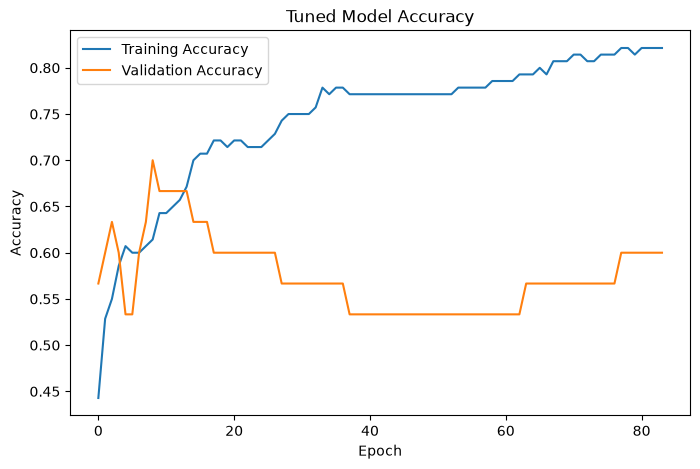

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    best_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Tuned Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

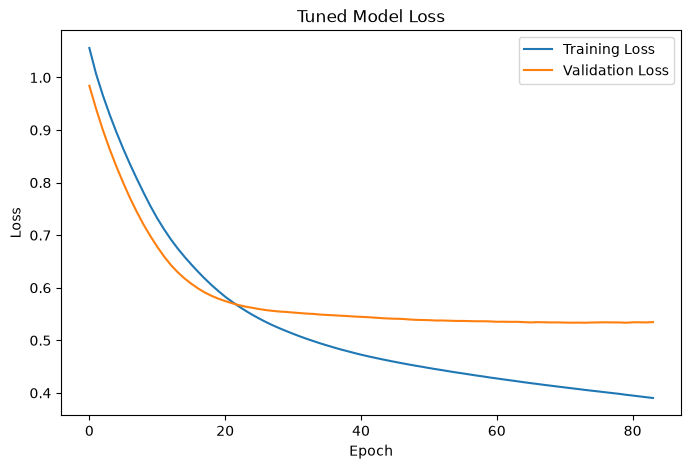

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    best_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Tuned Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()